# 🐛 MODULE 42 — DEBUGGING DEEP LEARNING MODELS
## 📒 NOTES — DATA PROBLEMS

> **Core principle:** When a Deep Learning model fails, **don't immediately blame the model**. First verify the data.

```text
DATA
 ↓
LABELS
 ↓
PREPROCESSING
 ↓
SHAPES
 ↓
SPLIT
 ↓
CLASS DISTRIBUTION
 ↓
MODEL
```

---

# 1. 🏷️ WRONG LABELS

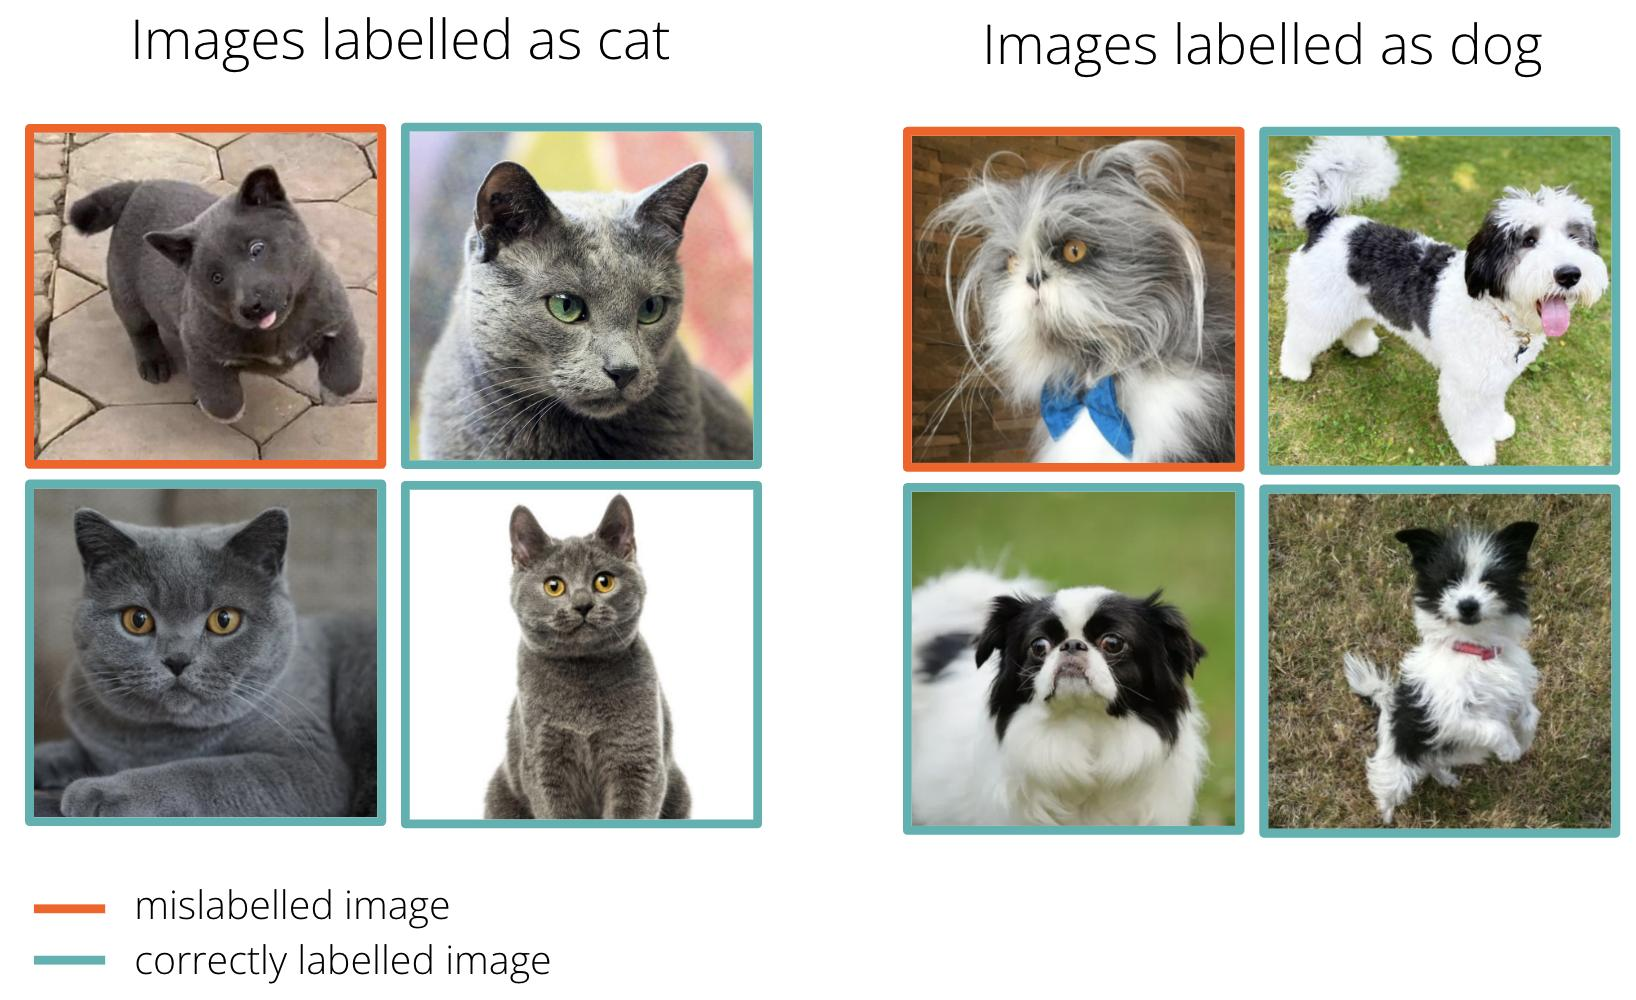

### 🔥🔥🔥 Must Know

A **wrong label** occurs when the target assigned to a training sample does not represent the actual sample.

Example:

```text
Image              Label
────────────────────────────
🐱                  Cat ✅
🐶                  Dog ✅
🐱                  Dog ❌
🐶                  Cat ❌
```



### 🧠 Why is this dangerous?

The model assumes:

> **The provided label is ground truth.**

Therefore:

```text
Image
  ↓
Model
  ↓
Prediction
  ↓
Compare with WRONG label
  ↓
Wrong loss signal
  ↓
Wrong gradient
  ↓
Poor learning
```

The model can therefore learn patterns that don't actually correspond to the desired task.

### 🔍 How to detect it

Visually inspect:

- Random training samples
- Their labels
- Samples from every class
- Misclassified samples
- Suspicious/outlier samples

```python
for images, labels in train_loader:
    # visualize images + labels
    pass
```

### 💡 Key debugging rule

> **Always inspect the actual data together with its labels.**

---

# 2. 📊 WRONG NORMALIZATION

### 🔥🔥🔥 Must Know

Neural networks are sensitive to the numerical scale/distribution of their inputs.

For an image:

```text
Raw pixel
0 ─────────────── 255
```

can be converted to:

```text
0 ─────────────── 1
```

and then standardized using channel-wise statistics.



### 🚨 Common problems

#### ❌ 1. No normalization

Training expects normalized inputs but receives raw values.

#### ❌ 2. Wrong mean/std

The model expects one distribution but receives another.

#### ❌ 3. Inconsistent preprocessing

```text
TRAIN
Image → Normalize → Model

TEST
Image → ❌ No normalization → Model
```

#### ❌ 4. Double normalization

```text
Image
 ↓
Normalize
 ↓
Normalize AGAIN ❌
 ↓
Model
```

### 🔍 Debugging

Inspect the tensor statistics:

```python
print(images.min())
print(images.max())
print(images.mean())
print(images.std())
```

Ask:

> **Are these values consistent with the preprocessing pipeline I intended to use?**

### 🧠 Important

For pretrained models, always verify the preprocessing expected by that particular model.

---

# 3. 📐 SHAPE MISMATCH

### 🔥🔥🔥 Must Know

Deep Learning operations require tensors with compatible dimensions.

For image models, a common PyTorch format is:

```text
[B, C, H, W]
```

where:

- **B** = Batch
- **C** = Channels
- **H** = Height
- **W** = Width

Example:

```text
[32, 3, 224, 224]
 │   │   │    │
 │   │   │    └── Width
 │   │   └─────── Height
 │   └─────────── Channels
 └─────────────── Batch
```



### 🚨 Common mistake

Expected:

```text
[B, C, H, W]
```

but received:

```text
[B, H, W, C]
```

This is a different tensor layout.

### 🔍 Debugging technique

Print shapes **before the failing operation**:

```python
print("Input:", x.shape)
print("Labels:", y.shape)
print("Output:", outputs.shape)
```

### 🧠 Shape-debugging mindset

Don't randomly modify the architecture.

Instead trace:

```text
Dataset
 ↓
DataLoader
 ↓
Input Tensor
 ↓
Layer 1
 ↓
Layer 2
 ↓
...
 ↓
Output
```

At each stage:

> **What shape should I have?**

---

# 4. ☠️ DATA LEAKAGE

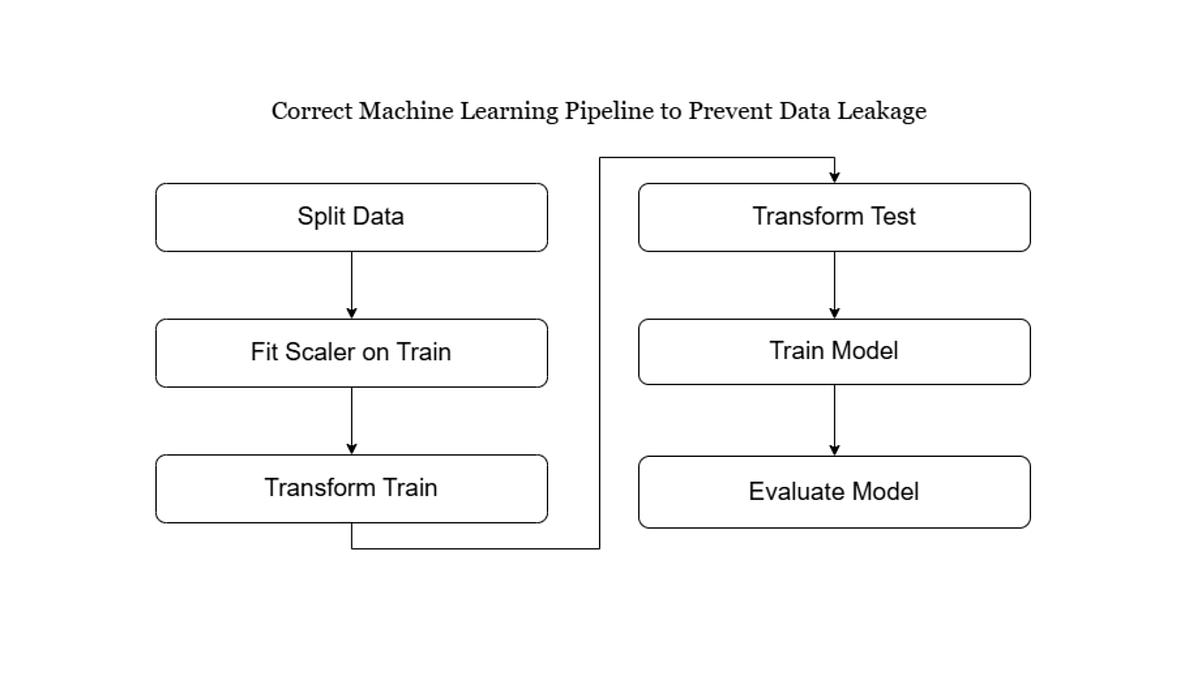

### 🔥🔥🔥 Must Know

**Data leakage** occurs when information that should not be available during training influences the learning process.



### ✅ Correct idea

```text
                  DATA
                    │
          ┌─────────┴─────────┐
          ↓                   ↓
       TRAIN                TEST
          │
      VALIDATION
```

The evaluation data should represent **unseen information**.

---

## 🚨 Example — Duplicate Data

Suppose:

```text
TRAIN
photo_001.jpg

TEST
photo_001_copy.jpg
```

The model may effectively encounter the same information in both sets.

This can produce:

```text
Validation accuracy → Very high 😍
Test accuracy       → Very high 😍
Real-world accuracy → Much lower 😭
```

### 🚨 Example — Future Information

Imagine predicting tomorrow's value.

If your input contains information that only becomes available **tomorrow**, the model has access to information unavailable during real inference.

That's leakage.

### 🧠 Key principle

> **Never allow information from the evaluation/future environment to influence the training process.**

### 🔍 Things to check

- Duplicate samples
- Train/test contamination
- Validation contamination
- Preprocessing performed using inappropriate data
- Future information
- Features derived from the target
- Group leakage

---

# 5. ⚖️ CLASS IMBALANCE

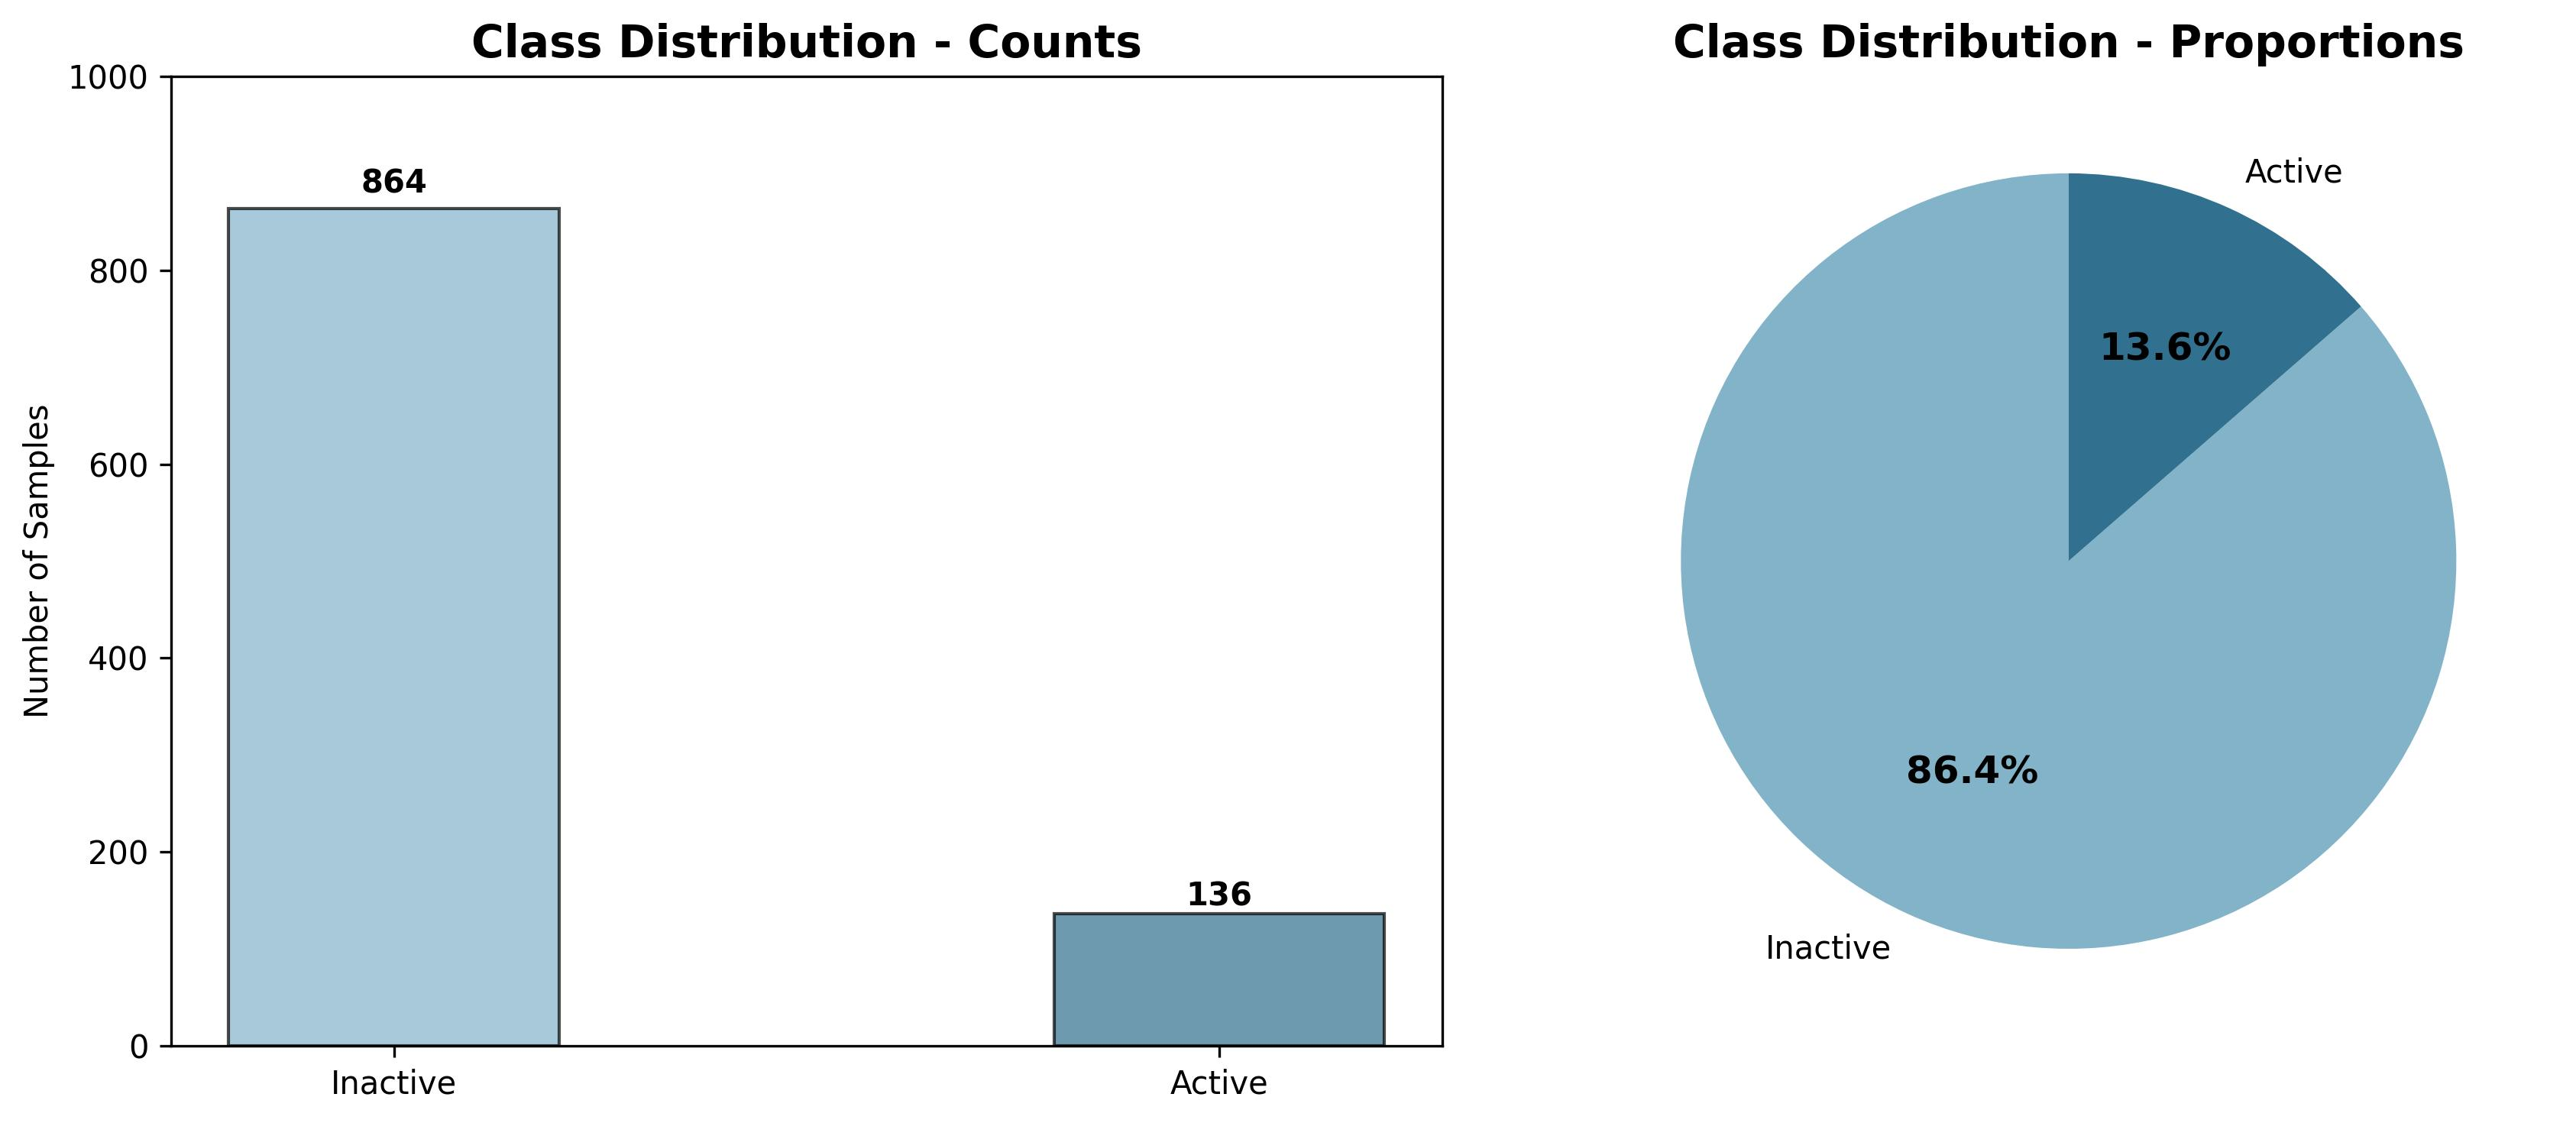
### 🔥🔥🔥 Must Know

**Class imbalance** occurs when some classes have significantly more samples than others.

Example:

```text
Cat       ████████████████████ 5000
Dog       ██████████████████   4500
Horse     ██                    500
```



### 🚨 Extreme example

Suppose:

```text
99% → Healthy
 1% → Disease
```

A model that always predicts:

```text
Healthy
```

gets:

> **99% accuracy**

😱

But it detects **zero disease cases**.

Therefore:

> **High accuracy ≠ good model.**

---

## 🔍 Detecting class imbalance

Check the number of samples in each class.

```python
from collections import Counter

print(Counter(labels))
```

Example:

```text
Class 0 → 9500
Class 1 → 500
```

That's a major imbalance.

---

## 🛠️ Possible solutions

### 1. Class weighting

Give greater importance to minority-class errors.

```text
Minority class
      ↓
Higher loss weight
      ↓
Model pays more attention
```

### 2. Oversampling

Increase the representation of minority samples.

```text
Minority
 ↓
More training samples
```

### 3. Undersampling

Reduce the number of majority-class samples.

### 4. Better data collection

Often the most fundamental solution:

> **Collect more representative data.**

---

# 🧠 THE 5 DATA PROBLEMS

| Problem | What is wrong? | What to check |
|---|---|---|
| 🏷️ Wrong labels | Target doesn't match sample | Inspect samples + labels |
| 📊 Wrong normalization | Input distribution is incorrect | min/max/mean/std |
| 📐 Shape mismatch | Tensor dimensions incompatible | `.shape` at each stage |
| ☠️ Data leakage | Unavailable information enters training | Train/test pipeline |
| ⚖️ Class imbalance | Classes have unequal representation | Class counts/distribution |

---

# 🔥 DATA-FIRST DEBUGGING CHECKLIST

When your model isn't performing correctly:

```text
                 MODEL FAILING
                      │
                      ↓
               CHECK THE DATA
                      │
       ┌──────────────┼──────────────┐
       ↓              ↓              ↓
    Labels      Normalization      Shapes
       │              │              │
       └──────────────┼──────────────┘
                      ↓
                Data Leakage?
                      ↓
                Class Balance?
                      ↓
             THEN CHECK MODEL
```

### 🧠 Golden rule

> **Before changing your architecture, make sure you can trust your data.**

---

# 💻 QUICK DEBUGGING CODE

A simple first-pass inspection:

```python
images, labels = next(iter(train_loader))

print("Image shape :", images.shape)
print("Label shape :", labels.shape)

print("Min :", images.min().item())
print("Max :", images.max().item())
print("Mean:", images.mean().item())
print("Std :", images.std().item())
```

Then inspect:

```text
✅ Images
✅ Labels
✅ Shapes
✅ Numerical range
✅ Mean / standard deviation
✅ Class distribution
```

This catches a surprising number of real-world problems.

---

# 🎯 INTERVIEW QUESTIONS

### Q1. Why can wrong labels prevent a model from learning?

Because the model receives an incorrect target and therefore receives misleading loss/gradient signals.

### Q2. Why is normalization important?

It puts inputs into an appropriate numerical distribution and helps make training stable and effective.

### Q3. What is data leakage?

When information that should be unavailable during training/evaluation influences the learning process.

### Q4. Why can 99% accuracy be misleading?

If the dataset is highly imbalanced, the model may simply predict the majority class.

### Q5. What is your first step when you see a tensor shape error?

**Inspect the shapes of the tensors involved**, rather than randomly changing the architecture.

---

# 🧠 ONE-MINUTE REVISION

```text
WRONG LABEL
→ Model learns from incorrect targets

WRONG NORMALIZATION
→ Model receives incorrect input distribution

SHAPE MISMATCH
→ Tensor dimensions don't match expectations

DATA LEAKAGE
→ Model gets information it shouldn't have

CLASS IMBALANCE
→ Some classes dominate the dataset
```

### 🔥 Remember this debugging order:

> **Inspect DATA → verify LABELS → verify PREPROCESSING → verify SHAPES → check LEAKAGE → check CLASS BALANCE → then investigate the MODEL.**

---

## 🔗 Useful Visual Resource

For interactive understanding of neural-network behavior, **TensorFlow Playground** is useful for visualizing how data, features, model architecture, and training interact.

[TensorFlow Playground](https://playground.tensorflow.org/?utm_source=chatgpt.com)

---